# Exploración CLR y PCA: taxonomía y funciones

La preparación es distinta para géneros MetaPhlAn y rutas funcionales HUMAnN,
pero ambas usan el mismo análisis modular: limpiar muestras, amalgamar rasgos
raros en `Other`, aplicar CLR, ajustar PCA, crear el biplot y exportar salidas.

En cada sección, cambia `ARROW_LABELS` según lo que quieras mostrar en las
flechas: `"names"`, `"numbers"` o `"none"`. Cuando se usan números, se guarda
una tabla de referencias en `results/tables/02_clr_pca_exploration/`.


In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

DATASETS = PROJECT_ROOT / "datasets"
FIGURES = PROJECT_ROOT / "results" / "figures" / "02_clr_pca_exploration"
TABLES = PROJECT_ROOT / "results" / "tables" / "02_clr_pca_exploration"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

METADATA = pd.read_excel(DATASETS / "metadata_LATINBIOTA_MEXICO.xlsx", sheet_name="Data")
OUTLIERS = [
    "37082_3#16", "37082_2#4", "37035_2#22",
    "37035_7#18", "36703_3#20", "36703_3#4",
]


## Funciones comunes


In [10]:
def remove_outlier_samples(abundance, outliers):
    # Elimina exclusivamente las muestras listadas como atípicas.
    return abundance.drop(index=outliers, errors="ignore").copy()


def keep_samples_with_lifestyle(abundance, metadata):
    # Alinea abundancias y conserva únicamente Rural/Urban.
    lifestyle = metadata.set_index("Lane")["Lifestyle"].reindex(abundance.index)
    valid = lifestyle.isin(["Rural", "Urban"])
    return abundance.loc[valid].copy(), lifestyle.loc[valid].copy()


def amalgamate_rare_features(abundance, prevalence=0.05, other_name="Other"):
    # Agrupa en Other las características presentes en pocas muestras.
    minimum_samples = max(1, int(np.ceil(prevalence * len(abundance))))
    keep = (abundance > 0).sum(axis=0) >= minimum_samples
    rare = abundance.columns[~keep]
    result = abundance.loc[:, abundance.columns[keep]].copy()
    if len(rare):
        result[other_name] = abundance.loc[:, rare].sum(axis=1)
    return result


def apply_clr(abundance):
    # Aplica CLR con pseudoconteo igual a la mitad del mínimo positivo.
    positive_values = abundance.where(abundance > 0).stack()
    if positive_values.empty:
        raise ValueError("No hay abundancias positivas para aplicar CLR.")
    pseudocount = positive_values.min() / 2
    log_abundance = np.log(abundance + pseudocount)
    return log_abundance.sub(log_abundance.mean(axis=1), axis=0)


def fit_pca(clr_data):
    # Ajusta PCA y devuelve coordenadas y cargas ordenadas por contribución.
    pca = PCA(n_components=2)
    scores = pd.DataFrame(pca.fit_transform(clr_data), index=clr_data.index, columns=["PC1", "PC2"])
    loadings = pd.DataFrame(pca.components_.T, index=clr_data.columns, columns=["PC1", "PC2"])
    loadings["contribution"] = np.hypot(loadings["PC1"], loadings["PC2"])
    return pca, scores, loadings.sort_values("contribution", ascending=False)


def plot_pca_biplot(scores, lifestyle, loadings, pca, title, top_features=8, arrow_labels="names"):
    # Crea el biplot; arrow_labels puede ser names, numbers o none.
    if arrow_labels not in {"names", "numbers", "none"}:
        raise ValueError("arrow_labels debe ser 'names', 'numbers' o 'none'.")

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    colors = {"Rural": "#2a9d8f", "Urban": "#e76f51"}
    for group in ["Rural", "Urban"]:
        points = scores.loc[lifestyle.eq(group)]
        ax.scatter(points.PC1, points.PC2, label=group, color=colors[group], s=42,
                   alpha=0.8, edgecolor="white", linewidth=0.5)

    selected = loadings.head(top_features).copy()
    selected.insert(0, "reference", range(1, len(selected) + 1))
    scale = scores.abs().to_numpy().max() / selected[["PC1", "PC2"]].abs().to_numpy().max() * 0.65
    for feature, row in selected.iterrows():
        x, y = row.PC1 * scale, row.PC2 * scale
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops={"arrowstyle": "->", "color": "#7f1d1d", "lw": 1.3})
        if arrow_labels == "names":
            label = feature
        elif arrow_labels == "numbers":
            label = str(row.reference)
        else:
            label = None
        if label is not None:
            ax.text(x * 1.08, y * 1.08, label, fontsize=8, color="#7f1d1d",
                    ha="center", va="center", fontweight="bold")

    ax.axhline(0, color="0.65", lw=0.7)
    ax.axvline(0, color="0.65", lw=0.7)
    ax.grid(alpha=0.2, linestyle="--")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title)
    ax.legend(title="Lifestyle", frameon=False)
    fig.tight_layout()
    return fig, selected.reset_index(names="feature")


def export_pca_results(name, scores, lifestyle, loadings, references, figure):
    # Guarda coordenadas, cargas, referencias de flechas y figura final.
    scores.assign(Lifestyle=lifestyle).to_csv(TABLES / f"{name}_pca_scores.csv")
    loadings.to_csv(TABLES / f"{name}_pca_loadings.csv")
    references.to_csv(TABLES / f"{name}_arrow_references.csv", index=False)
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.pdf", bbox_inches="tight")


def run_clr_pca(abundance, name, title, prevalence=0.05, top_features=8, arrow_labels="names"):
    # Orquesta el flujo común y devuelve los resultados para inspección.
    abundance = abundance.apply(pd.to_numeric, errors="coerce").fillna(0)
    abundance = remove_outlier_samples(abundance, OUTLIERS)
    abundance, lifestyle = keep_samples_with_lifestyle(abundance, METADATA)
    abundance = amalgamate_rare_features(abundance, prevalence=prevalence)
    clr_data = apply_clr(abundance)
    pca, scores, loadings = fit_pca(clr_data)
    figure, references = plot_pca_biplot(
        scores, lifestyle, loadings, pca, title,
        top_features=top_features, arrow_labels=arrow_labels,
    )
    export_pca_results(name, scores, lifestyle, loadings, references, figure)
    plt.show()
    print(f"{name}: {len(abundance)} muestras, {abundance.shape[1]} características, PC1+PC2 = {pca.explained_variance_ratio_[:2].sum():.1%}")
    if arrow_labels == "numbers":
        print("Referencias de las flechas:")
        print(references[["reference", "feature", "contribution"]].to_string(index=False))
    return {"scores": scores.assign(Lifestyle=lifestyle), "loadings": loadings,
            "references": references, "clr": clr_data, "pca": pca}


## 1. Taxonomía: géneros de MetaPhlAn


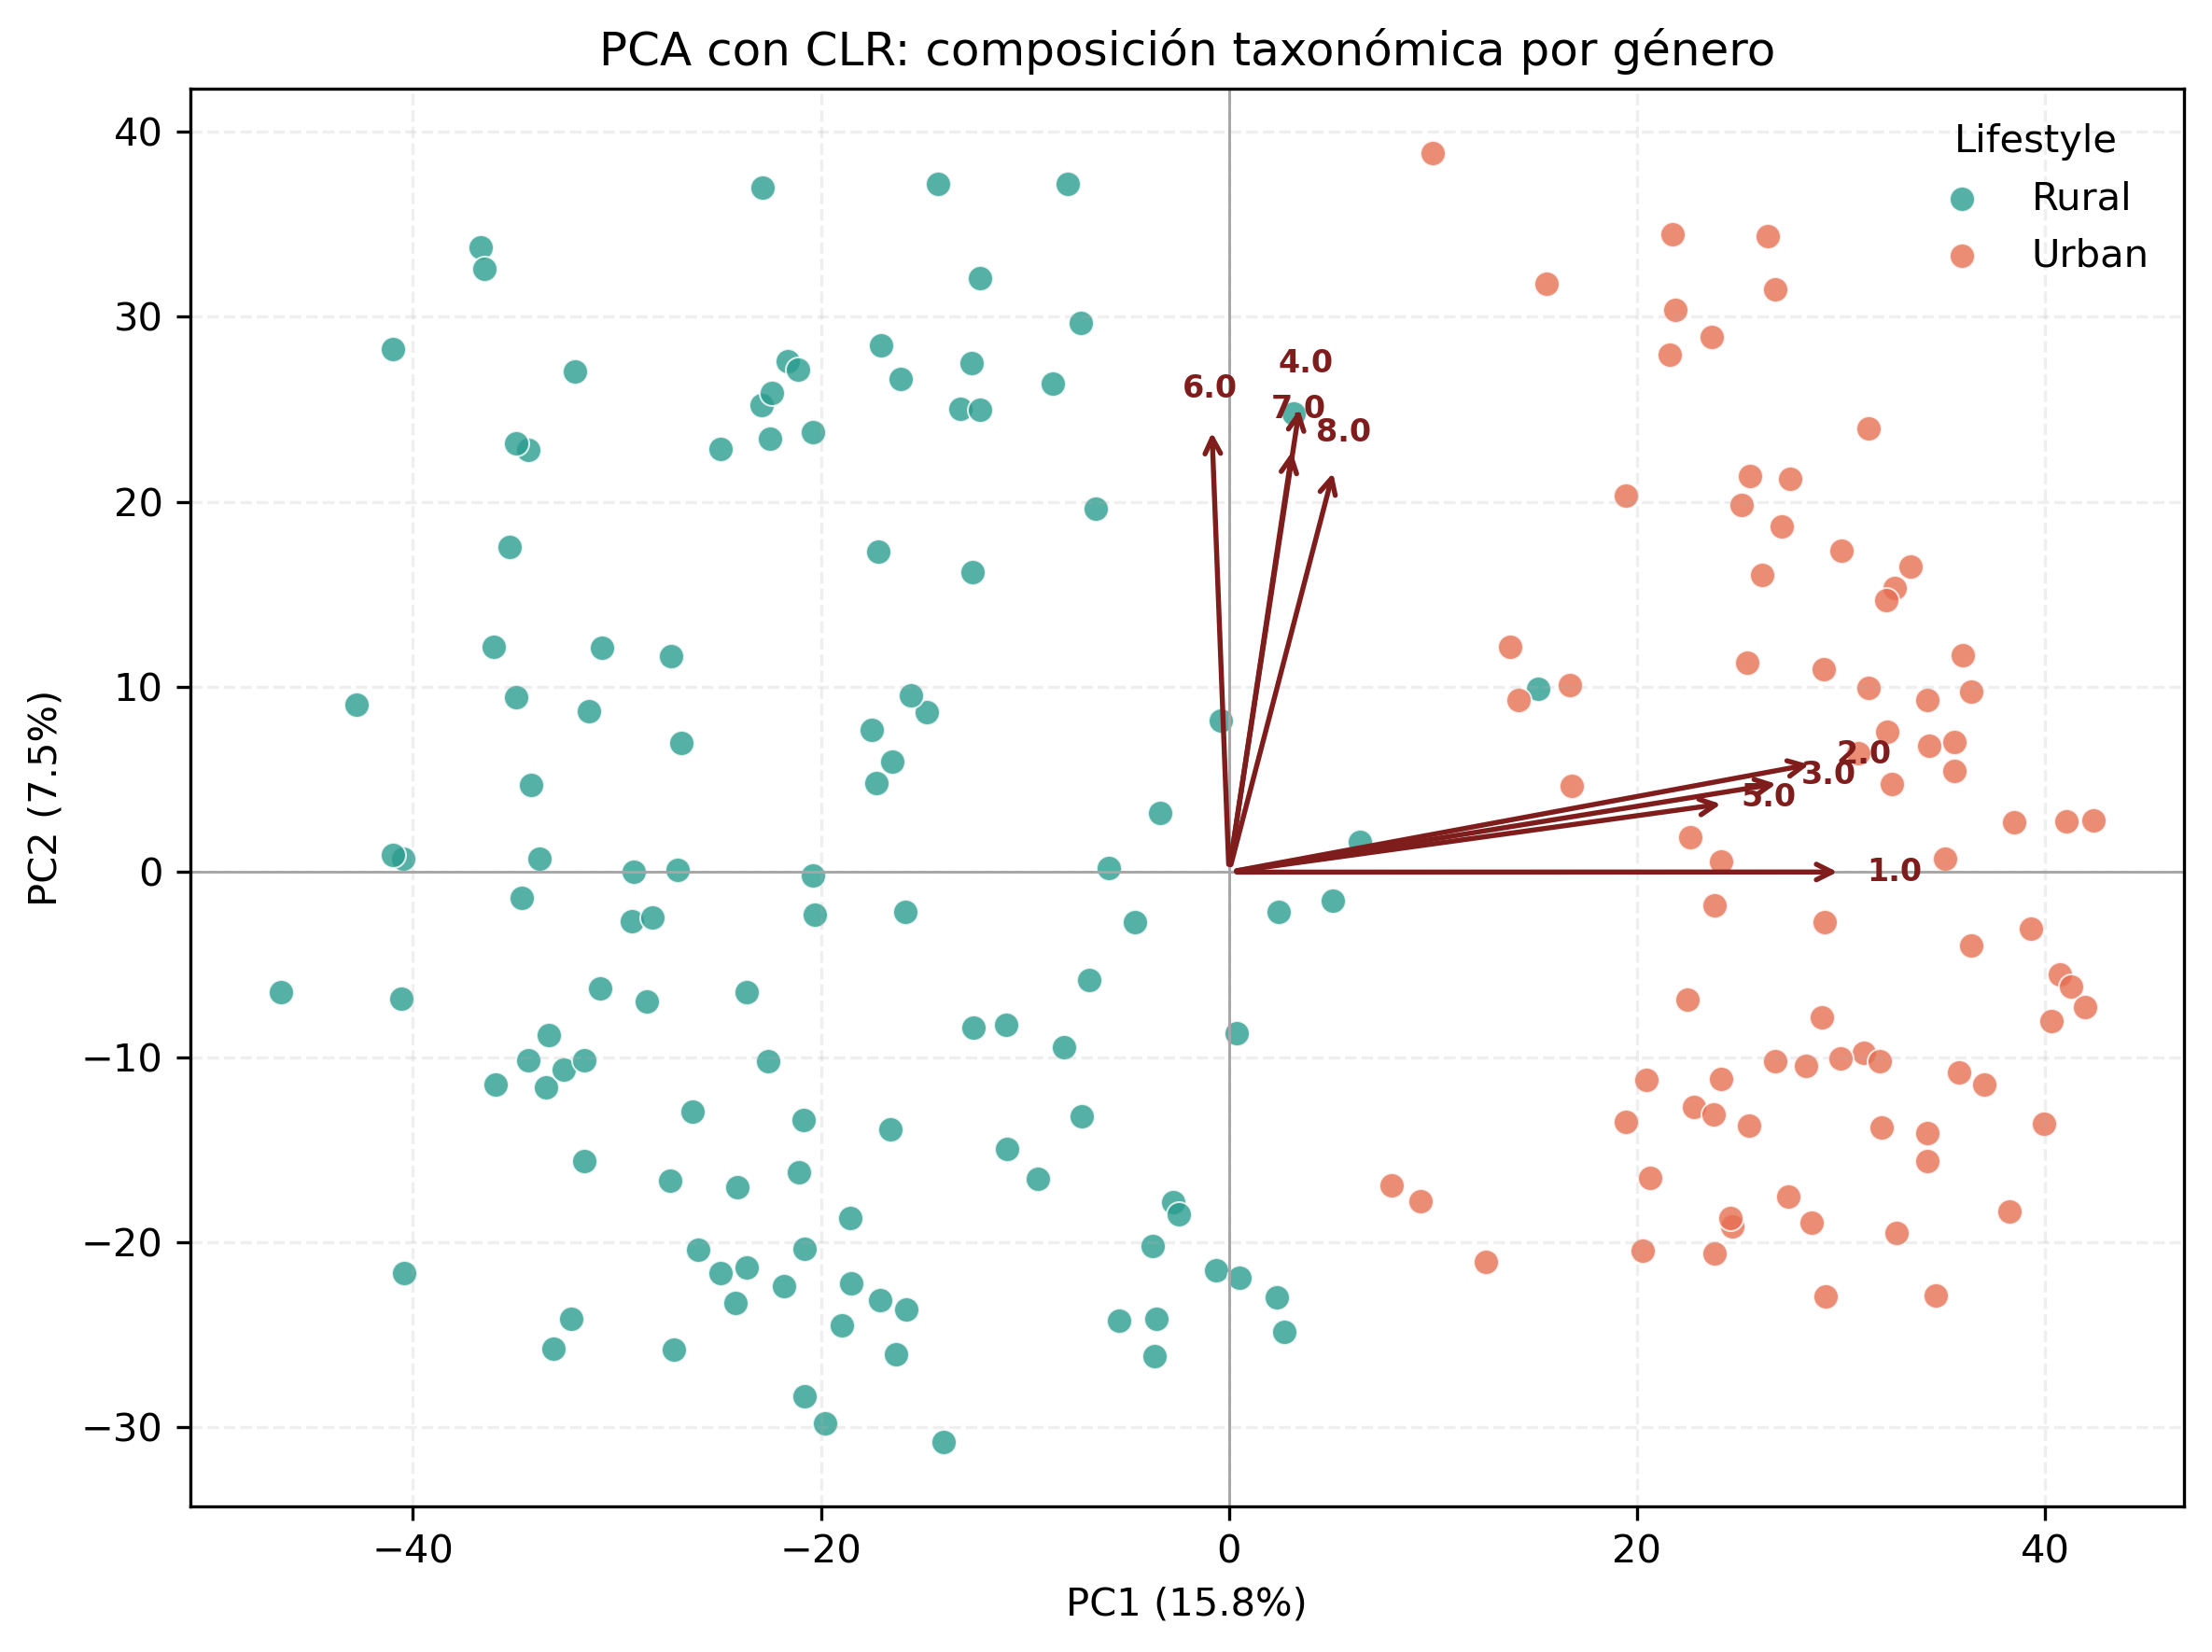

taxonomic_genus: 199 muestras, 618 características, PC1+PC2 = 23.3%
Referencias de las flechas:
 reference         feature  contribution
         1     Phocaeicola      0.187990
         2     Bacteroides      0.183011
         3       Alistipes      0.171926
         4         GGB9708      0.159709
         5 Parabacteroides      0.154183
         6         GGB9634      0.150521
         7         GGB3304      0.145275
         8         GGB9747      0.140521


,PC1,PC2,contribution
Phocaeicola,0.187990,0.000041,0.187990
Bacteroides,0.179305,0.036641,0.183011
Alistipes,0.169270,0.030108,0.171926
GGB9708,0.021812,0.158212,0.159709
Parabacteroides,0.152422,0.023233,0.154183
GGB9634,-0.005270,0.150429,0.150521
GGB3304,0.019587,0.143949,0.145275
GGB9747,0.032343,0.136748,0.140521
Faecalibacillus,0.030166,-0.133619,0.136982
GGB9712,0.007929,0.132956,0.133193


In [11]:
# Preparación exclusiva de MetaPhlAn: taxones × muestras → géneros × muestras.
ARROW_LABELS = "numbers"  # Elegir: "names", "numbers" o "none".

metaphlan = pd.read_csv(DATASETS / "latinbiota_merge_metaphlan_data.csv", sep="\t", skiprows=1, index_col=0)
taxon_names = metaphlan.index.astype(str)
is_genus = (
    taxon_names.str.contains(r"(?:^|\|)g__", regex=True)
    & ~taxon_names.str.contains(r"(?:^|\|)[ts]__", regex=True)
    & ~taxon_names.str.contains("unclassified", case=False)
)
genus = metaphlan.loc[is_genus].copy()
genus.index = [name.split("|g__", 1)[1].split("|", 1)[0].replace("_", " ") for name in genus.index]
genus = genus.groupby(level=0).sum().T

genus_result = run_clr_pca(
    genus, "taxonomic_genus", "PCA con CLR: composición taxonómica por género",
    arrow_labels=ARROW_LABELS,
)
genus_result["loadings"].head(10)


![Biplot taxonómico final](../results/figures/02_clr_pca_exploration/taxonomic_genus_biplot_final.png)


## 2. Funcional: rutas no estratificadas de HUMAnN


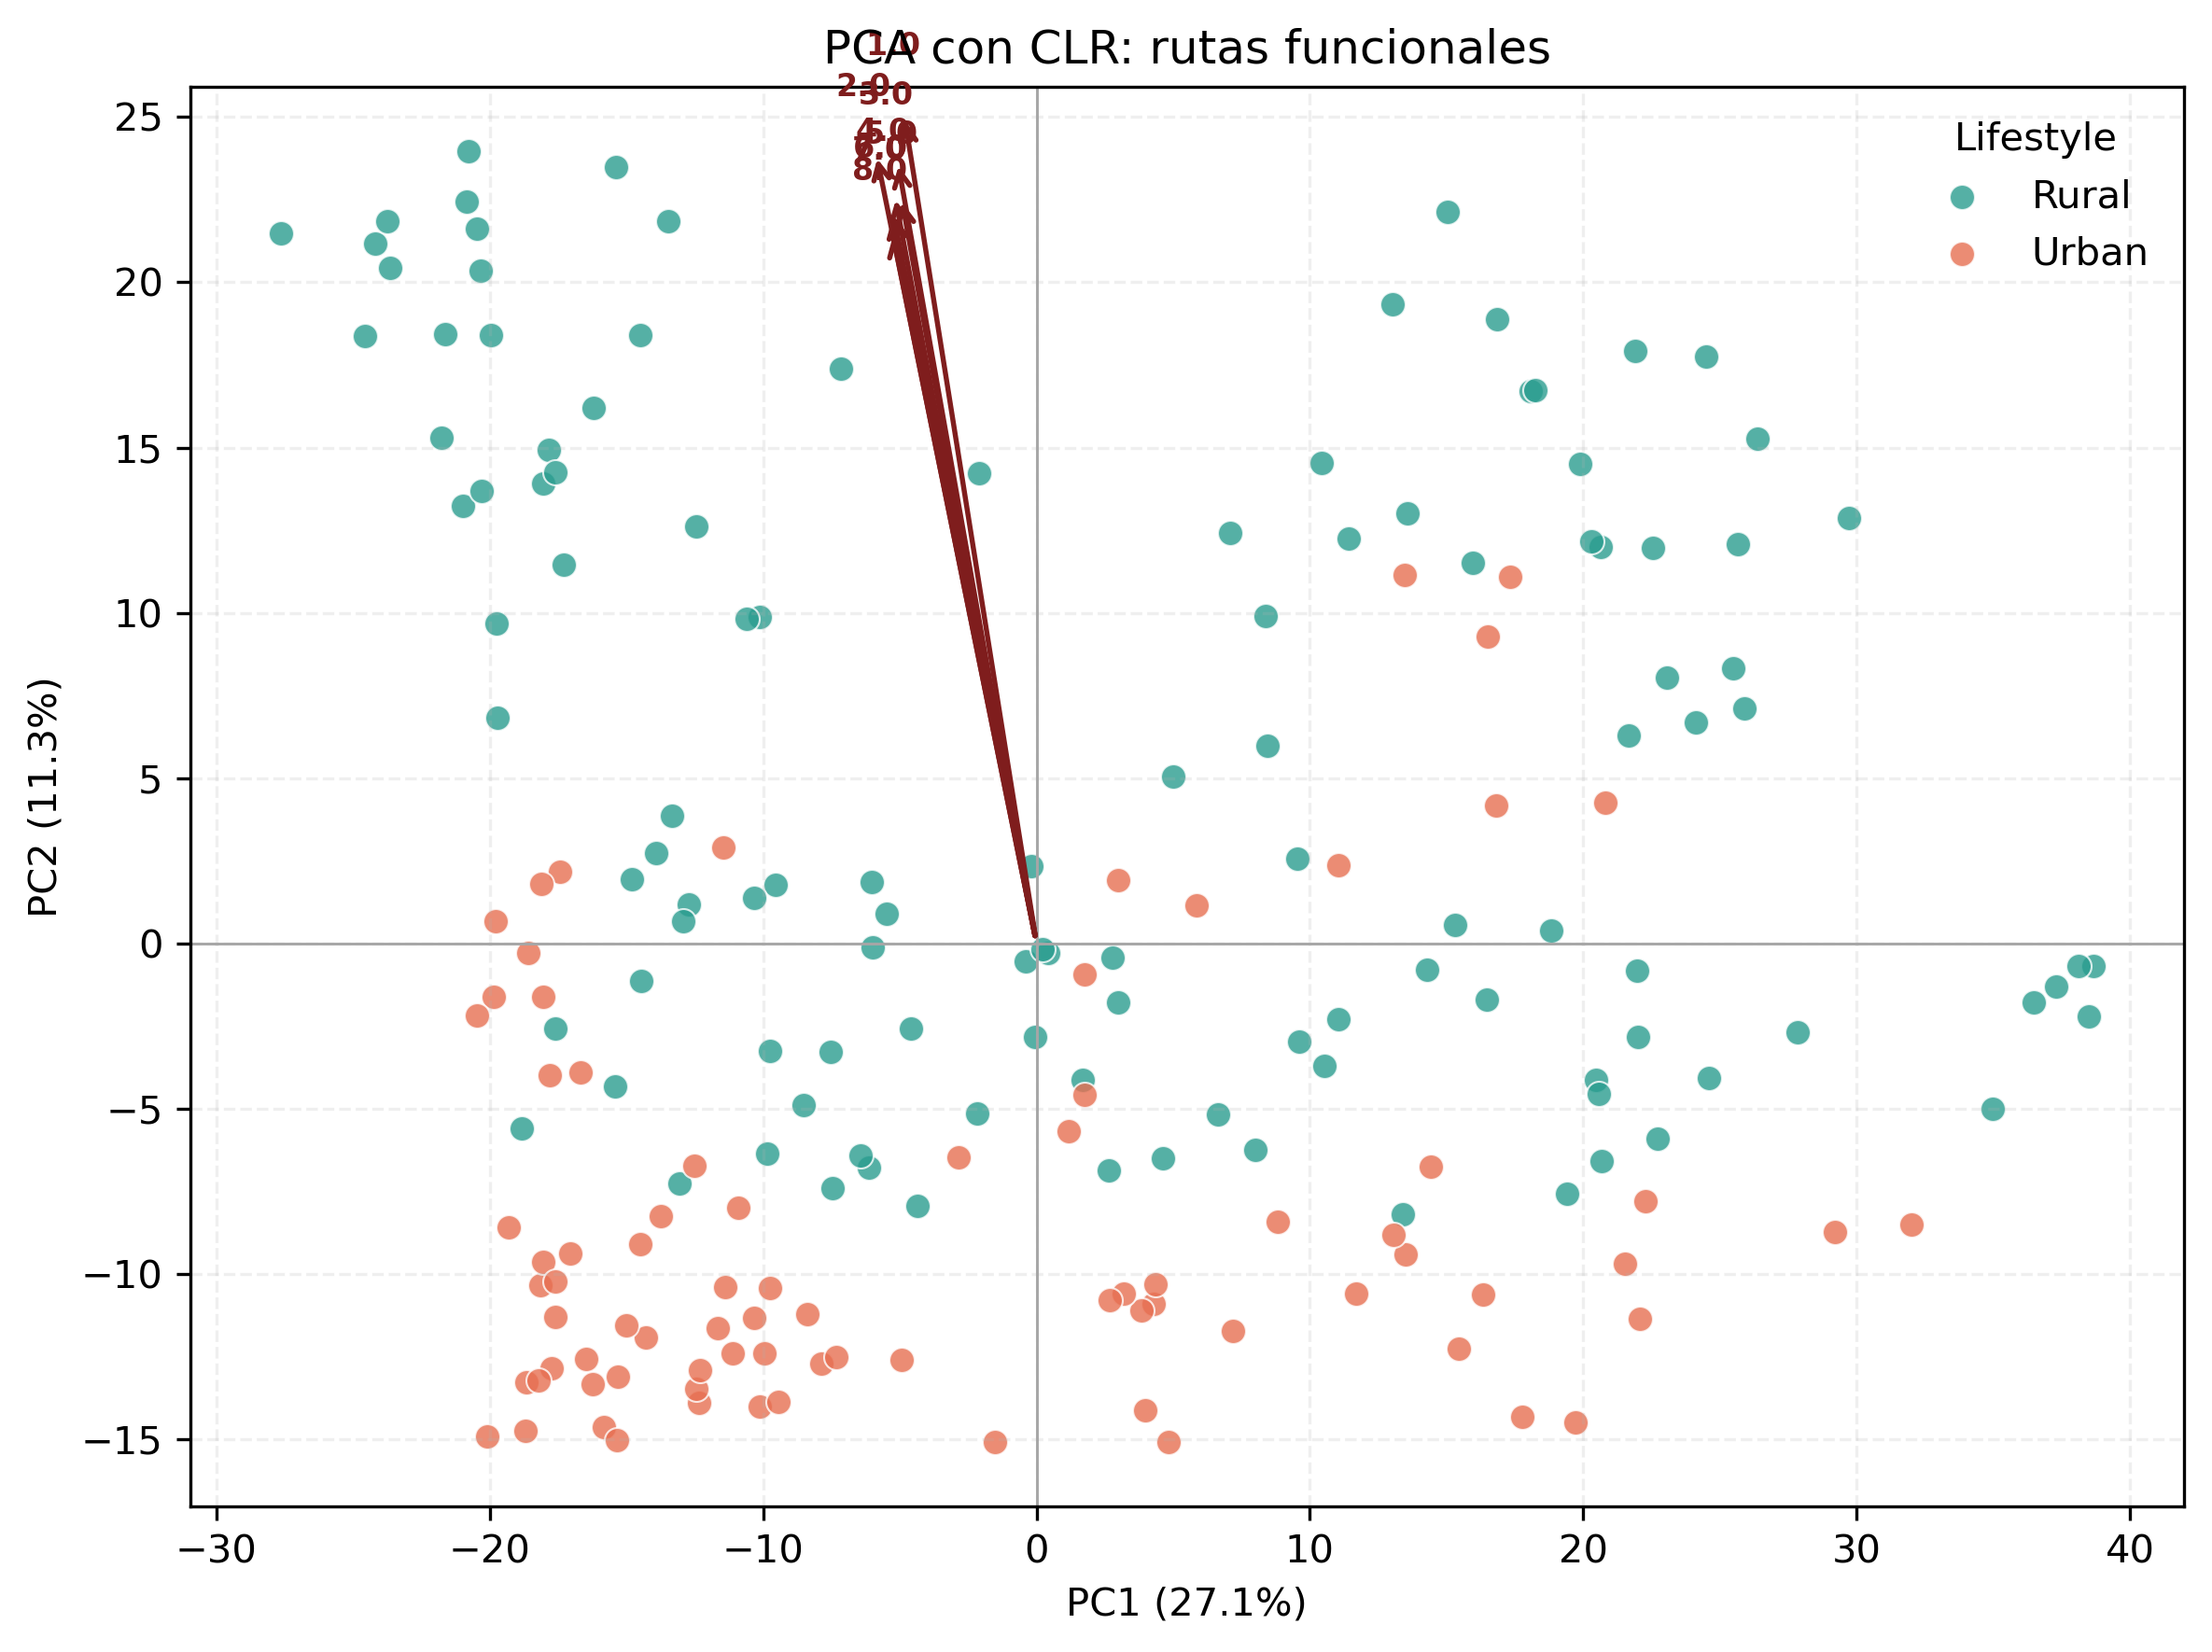

functional_pathways: 199 muestras, 475 características, PC1+PC2 = 38.4%
Referencias de las flechas:
 reference                                                         feature  contribution
         1                      PWY-6167: flavin biosynthesis II (archaea)      0.219061
         2                  PWY-6165: chorismate biosynthesis II (archaea)      0.211248
         3                               PWY-5196: factor 430 biosynthesis      0.207918
         4      PWY-7286: 7-(3-amino-3-carboxypropyl)-wyosine biosynthesis      0.199485
         5 PWY-6654: phosphopantothenate biosynthesis III (archaebacteria)      0.198544
         6              METHANOGENESIS-PWY: methanogenesis from H2 and CO2      0.195719
         7                    PWY-5209: methyl-coenzyme M oxidation to CO2      0.195440
         8             PWY-5198: factor 420 biosynthesis II (mycobacteria)      0.190706


,PC1,PC2,contribution
# Pathway,,,
PWY-6167: flavin biosynthesis II (archaea),-0.041544,0.215086,0.219061
PWY-6165: chorismate biosynthesis II (archaea),-0.050329,0.205165,0.211248
PWY-5196: factor 430 biosynthesis,-0.043631,0.203288,0.207918
PWY-7286: 7-(3-amino-3-carboxypropyl)-wyosine biosynthesis,-0.044557,0.194445,0.199485
PWY-6654: phosphopantothenate biosynthesis III (archaebacteria),-0.042490,0.193944,0.198544
METHANOGENESIS-PWY: methanogenesis from H2 and CO2,-0.045183,0.190432,0.195719
PWY-5209: methyl-coenzyme M oxidation to CO2,-0.045523,0.190064,0.195440
PWY-5198: factor 420 biosynthesis II (mycobacteria),-0.045400,0.185223,0.190706
P261-PWY: coenzyme M biosynthesis I,-0.043848,0.184944,0.190071


In [12]:
# Preparación exclusiva de HUMAnN: eliminar filas no asignadas y transponer rutas × muestras.
ARROW_LABELS = "numbers"  # Elegir: "names", "numbers" o "none".

functional = pd.read_csv(DATASETS / "latinbiota_pathabundance_unstratified_relab.tsv", sep="\t", index_col=0)
functional = functional.drop(index=["UNMAPPED", "UNINTEGRATED"], errors="ignore")
functional = functional.loc[:, ~functional.columns.str.contains(r"\.1", regex=True)]
functional = functional.T
functional.index = functional.index.str.replace("_paired_Abundance", "", regex=False)

functional_result = run_clr_pca(
    functional, "functional_pathways", "PCA con CLR: rutas funcionales",
    arrow_labels=ARROW_LABELS,
)
functional_result["loadings"].head(10)


![Biplot funcional final](../results/figures/02_clr_pca_exploration/functional_pathways_biplot_final.png)
